In [1]:
# Importing the Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import pyplot
from sklearn.feature_selection import SelectKBest, mutual_info_regression
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.preprocessing import RobustScaler, LabelEncoder
from scipy.stats import pearsonr
from scipy.stats import linregress
from sklearn.svm import SVR

In [3]:
# load the dataset
data = pd.read_excel('BBDM Project for 2nd research article.xlsx')

# Columns to exclude
columns_to_exclude = ['Chainage','Formation','RMC']

# Prepare Features and Target
X = data.drop(['PRnet'] + columns_to_exclude, axis=1)
Y = data['PRnet']

# Label encoding for multiple columns
label_encoder = LabelEncoder()
for col in ['Lithology', 'Weathering', 'Rock Strength']:
    X[col] = label_encoder.fit_transform(X[col])

In [5]:
# Split the data into training, validation, and test sets
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# Data Standardization
scaler = RobustScaler()
scaler.fit(X_train)  # Fit on the training data
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)


# Create an instance of the SVR model with the specified parameters
model = SVR(C=50.0, gamma='scale', kernel='rbf')

# Train the model on the training set
model.fit(X_train_scaled, Y_train)

# Predict on the training data
Y_train_pred = model.predict(X_train_scaled)

# Train metrics
r2_train = r2_score(Y_train, Y_train_pred)
mae_train = mean_absolute_error(Y_train, Y_train_pred)
mse_train = mean_squared_error(Y_train, Y_train_pred)
rmse_train = np.sqrt(mse_train)
mape_train = np.mean(np.abs((Y_train - Y_train_pred) / Y_train)) * 100


# Predict on the test data
Y_test_pred = model.predict(X_test_scaled)

# Test metrics (already in your code, but grouped here for clarity)
r2_test = r2_score(Y_test, Y_test_pred)
mae_test = mean_absolute_error(Y_test, Y_test_pred)
mse_test = mean_squared_error(Y_test, Y_test_pred)
rmse_test = np.sqrt(mse_test)
mape_test = np.mean(np.abs((Y_test - Y_test_pred) / Y_test)) * 100


# Combine both into a DataFrame
metrics_df = pd.DataFrame({
    'Metric': ['R2', 'MAE', 'MSE', 'RMSE', 'MAPE'],
    'Train': [r2_train, mae_train, mse_train, rmse_train, mape_train],
    'Test': [r2_test, mae_test, mse_test, rmse_test, mape_test]
})

# Round to 3 decimal places
metrics_df[['Train', 'Test']] = metrics_df[['Train', 'Test']].round(3)

# Display the comparison
print(metrics_df)

  Metric   Train    Test
0     R2   0.927   0.936
1    MAE   2.018   2.187
2    MSE  17.424  15.966
3   RMSE   4.174   3.996
4   MAPE   3.039   3.410


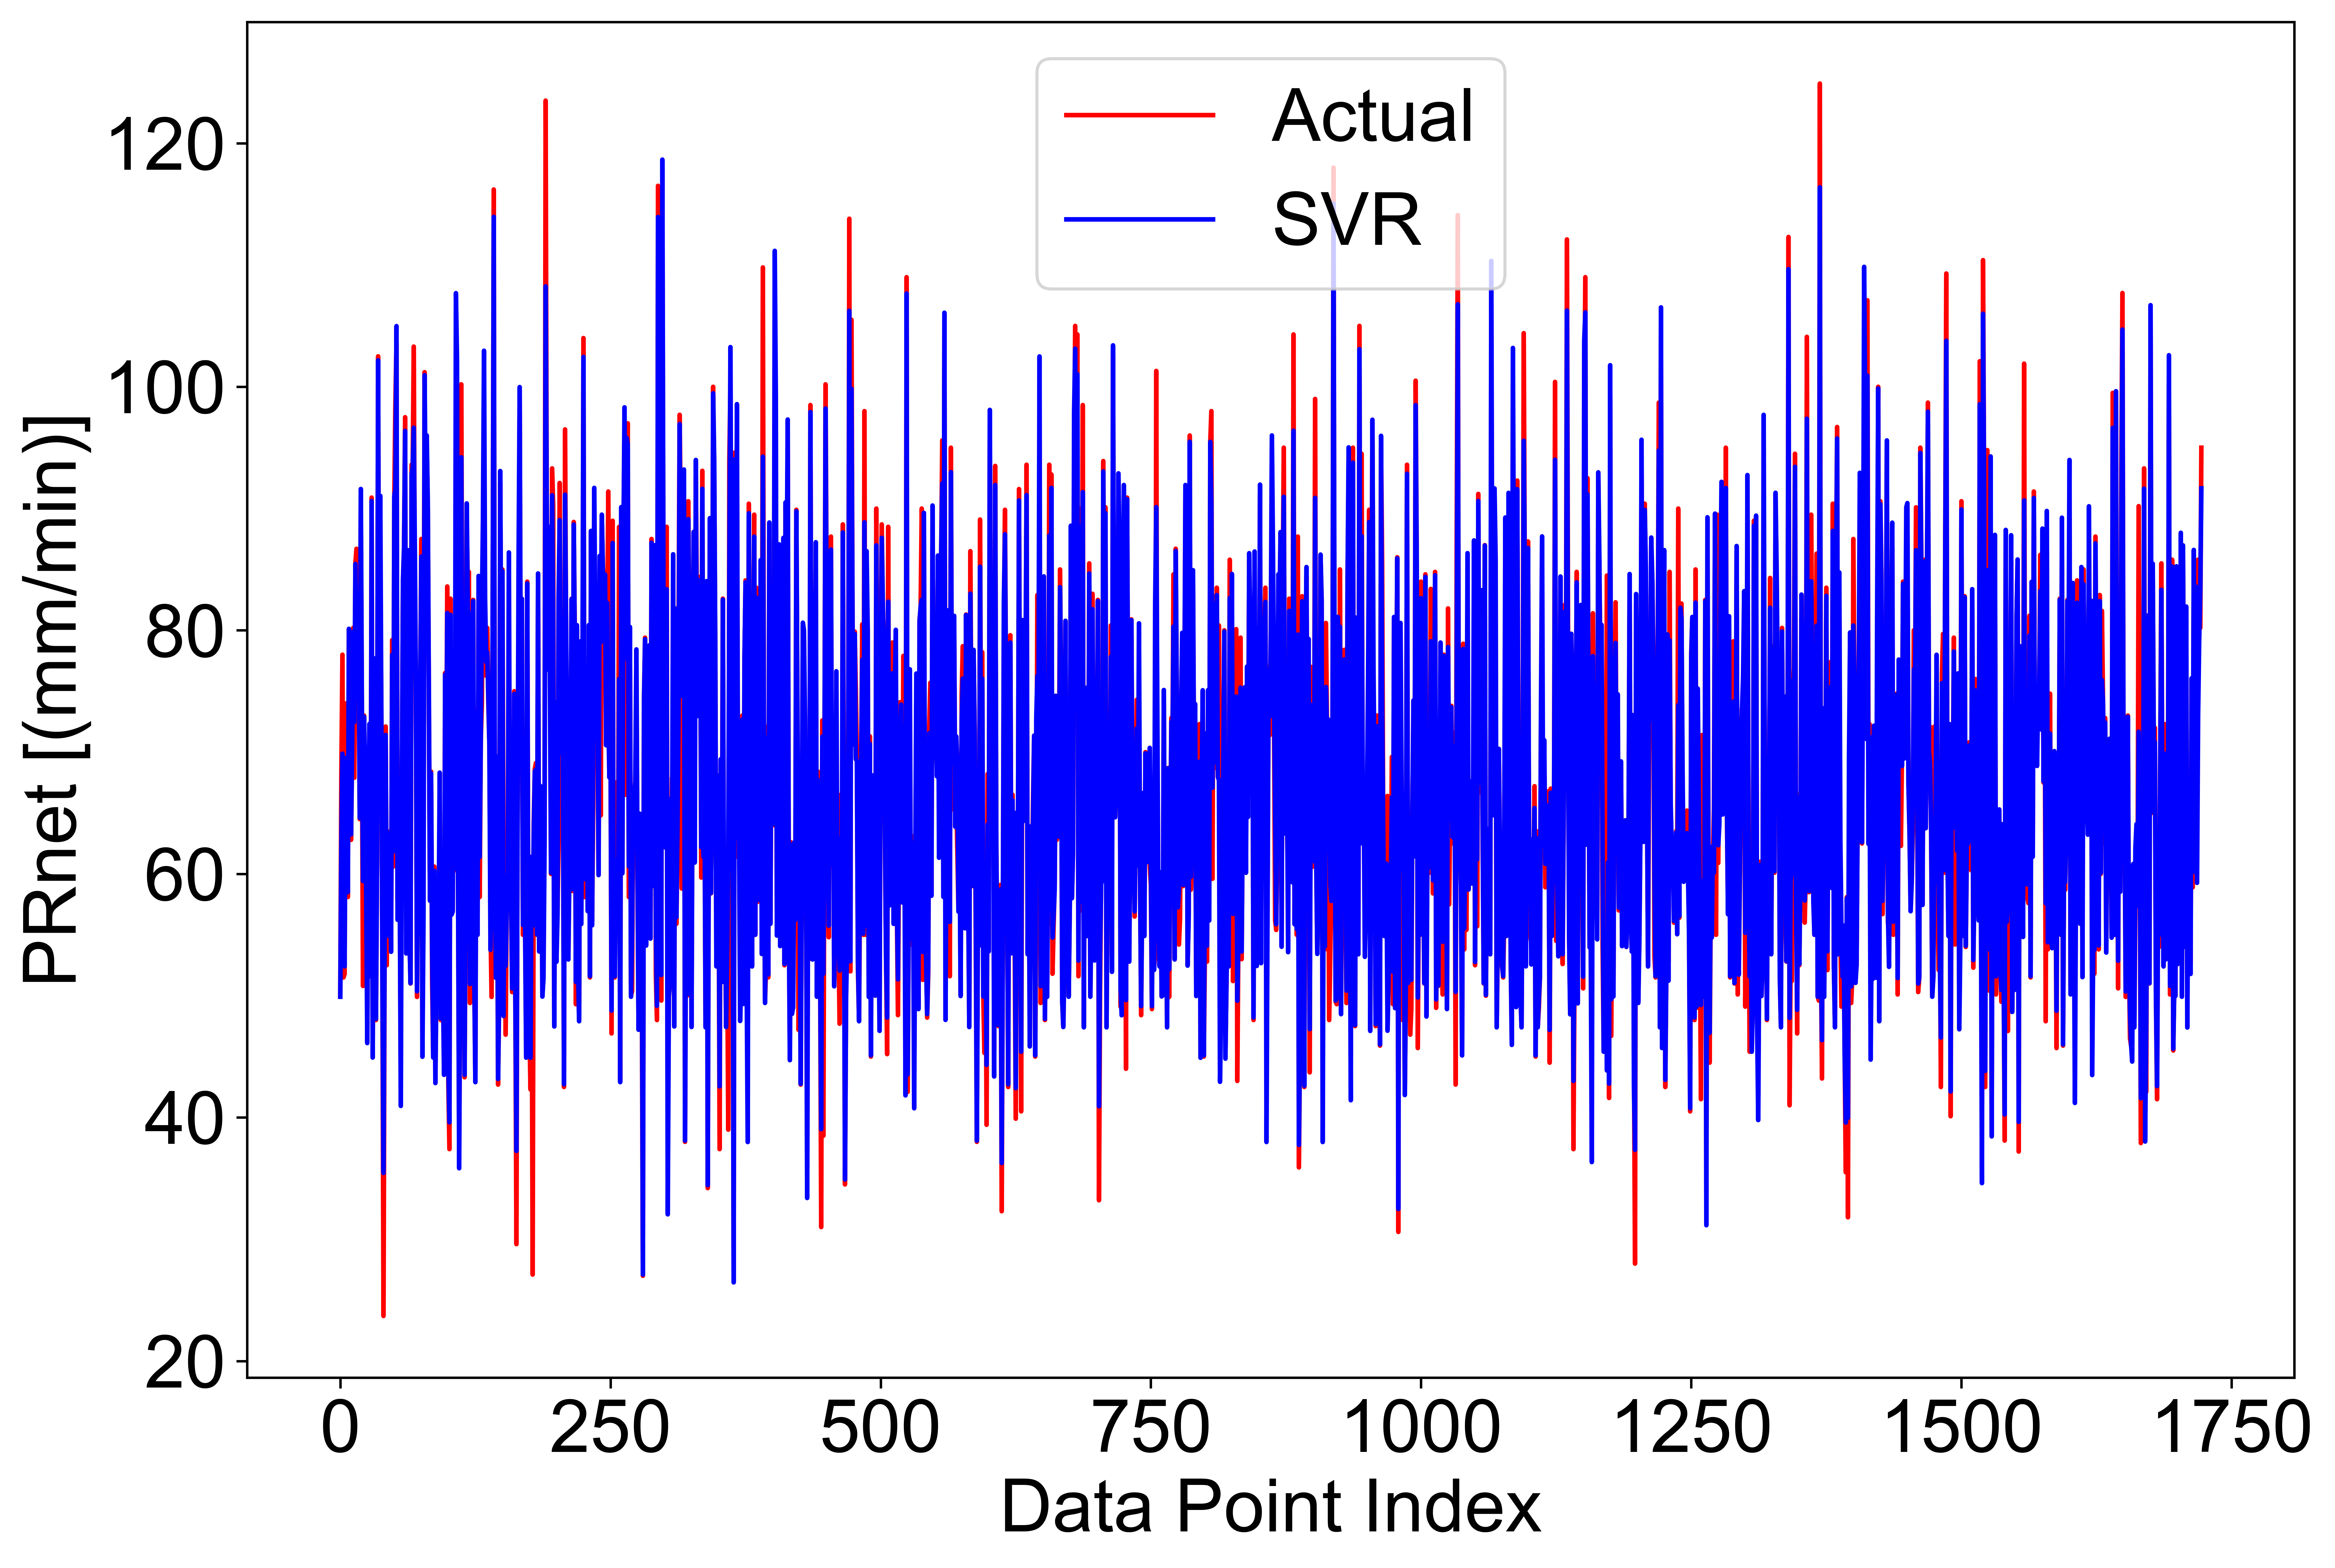

In [7]:
# Create a list of data point indices (numbers)
data_indices = range(len(Y_test))

# Create a line plot of actual vs. predicted Y values for the entire dataset
pyplot.rc('font', family='Arial')
plt.figure(figsize=(12, 8), dpi=800)
plt.plot(data_indices, Y_test, 'red', label='Actual')
plt.plot(data_indices, Y_test_pred, 'blue', label='SVR')
plt.xlabel('Data Point Index', fontsize=24)
plt.ylabel('PRnet [(mm/min)]', fontsize=24)
plt.title('', fontsize=24)
plt.xticks(fontsize=24)
plt.yticks(fontsize=24)
plt.legend(loc='best', fontsize=24)
plt.show()